# Лабораторная работа 8. Сверточные нейронные сети.

## Классификация кошек и собак

Загрузим изображения с кошками и собаками.

Поделим данные в формате 80 - 10 - 10.

In [24]:
import tensorflow as tf

train_ds, val_test_ds = tf.keras.utils.image_dataset_from_directory(
    "data3",
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=(200,400),
    batch_size=32,
)
val_and_test_batches = val_test_ds.cardinality().numpy()
val_and_test_batches

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Using 400 files for validation.


np.int64(13)

In [25]:
half_batches = val_and_test_batches // 2
val_ds = val_test_ds.take(half_batches)
test_ds = val_test_ds.skip(half_batches)

print(f"Батчей на обучение: {train_ds.cardinality().numpy()}")
print(f"Батчей на валидацию: {val_ds.cardinality().numpy()}")
print(f"Батчей на тест: {test_ds.cardinality().numpy()}")

Батчей на обучение: 50
Батчей на валидацию: 6
Батчей на тест: 7


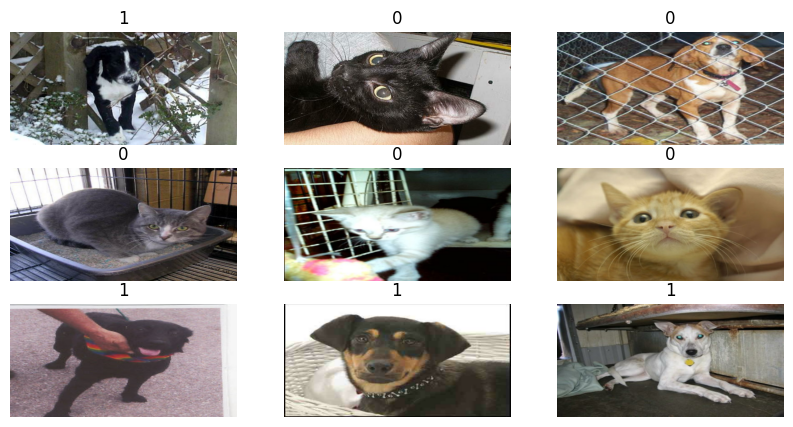

In [26]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 5))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")


### Аугментация

Выполним 5 видов аугментации.

* `RandomFlip` — случайное зеркальное отражение (влево-вправо).
* `RandomRotation` — случайный поворот (до 10%).
* `RandomZoom` — случайное приближение или отдаление (до 10%).
* `GaussianNoise` — наложение цифрового шума («помех» на пиксели).
* `RandomBrightness` — случайное изменение яркости (темнее/светлее)

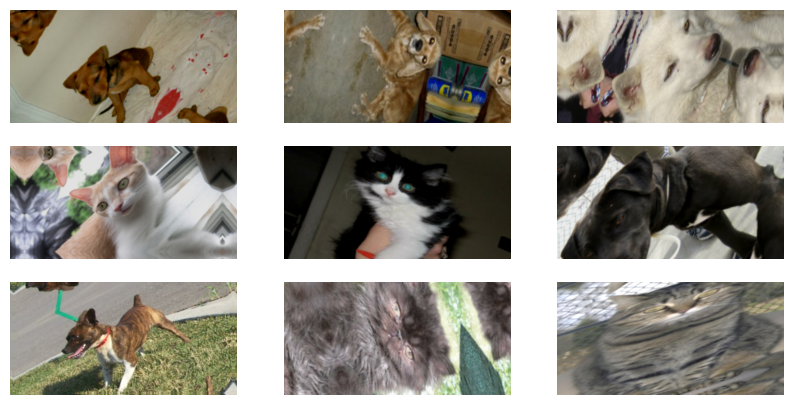

In [27]:
plt.figure(figsize=(10,5))

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.3),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.GaussianNoise(0.1),
        tf.keras.layers.RandomBrightness(factor=0.15),
    ]
)
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

### Сборка CNN

In [28]:
input = tf.keras.layers.Input(shape=(200,400,3))
x = data_augmentation(input)
x = tf.keras.layers.Rescaling(1.0 / 255)(x)

x = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPool2D(3, strides=2, padding="same")(x)

x = tf.keras.layers.Conv2D(128, 4, strides=2, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPool2D(3, strides=2, padding="same")(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)

x = tf.keras.layers.Dropout(0.5)(x)

output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 200, 400, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 200, 400, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 200, 400, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 100, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 50, 100, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 25, 50, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     2,662,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,795,521 (10.66 MB)

 Trainable params: 2,795,521 (10.66 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir="logs",
    write_graph=True
)
history = model.fit(train_ds,
          validation_data=(val_ds, None),
          epochs=35, callbacks=[tensorboard],
          verbose=1)

Epoch 1/35


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 299ms/step - accuracy: 0.5119 - loss: 0.7173 - val_accuracy: 0.4115 - val_loss: 0.6940
Epoch 2/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 278ms/step - accuracy: 0.5119 - loss: 0.6931 - val_accuracy: 0.4115 - val_loss: 0.6942
Epoch 3/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 298ms/step - accuracy: 0.5163 - loss: 0.6911 - val_accuracy: 0.4271 - val_loss: 0.7000
Epoch 4/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - accuracy: 0.5400 - loss: 0.6842 - val_accuracy: 0.5312 - val_loss: 0.6377
Epoch 5/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 283ms/step - accuracy: 0.5675 - loss: 0.6762 - val_accuracy: 0.5260 - val_loss: 0.6593
Epoch 6/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 290ms/step - accuracy: 0.5681 - loss: 0.6757 - val_accuracy: 0.4167 - val_loss: 0.6997
Epoch 7/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 275ms/step - accuracy: 0.5144 - loss: 0.6936 - val_accuracy: 0.4115 - val_loss: 0.6983
Epoch 8/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 279ms/step - accuracy: 0.5244 - loss: 0.6879 - val_accuracy: 0.479

### Визуализация при помощи tensorboard

In [30]:
%load_ext tensorboard
%tensorboard --logdir logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 18348), started 4:32:25 ago. (Use '!kill 18348' to kill it.)

По графику видно, что с увеличением числа эпох accuracy увеличивается. При этом на эпохах до 5 эта метрика крайне непостоянна - это объясняется тем, что модель в начале обучения обладала неоптимальными параметрами. Возможно, что с увеличением числа эпох эта метрика возрастет.

In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics_sigmoid(dataset, dataset_name):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)

        preds_classes = (preds >= 0.5).astype(int).flatten()

        y_true.extend(labels.numpy())
        y_pred.extend(preds_classes)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='binary'),
        "Recall": recall_score(y_true, y_pred, average='binary'),
        "F1-Score": f1_score(y_true, y_pred, average='binary')
    }


train_metrics = calculate_metrics_sigmoid(train_ds, "Train (Обучение)")
test_metrics = calculate_metrics_sigmoid(test_ds, "Test (Тест)")

df_metrics = pd.DataFrame([train_metrics, test_metrics]).set_index("Dataset")
df_metrics = df_metrics.round({
    "Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1-Score": 2
})

df_metrics

,Accuracy,Precision,Recall,F1-Score
Dataset,,,,
Train (Обучение),0.6925,0.7316,0.5857,0.65
Test (Тест),0.6875,0.7381,0.5905,0.66


Заметим, что модель обладает неплохим значением f1 = 0.66. При этом модель часто идентифицирует собак как кошек (recall = 0.59), кошек как собак модель классифицирует реже (precision = 0.73).

Попробуем выполнить предсказание на конкретных картинках.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[0.53671896]]


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

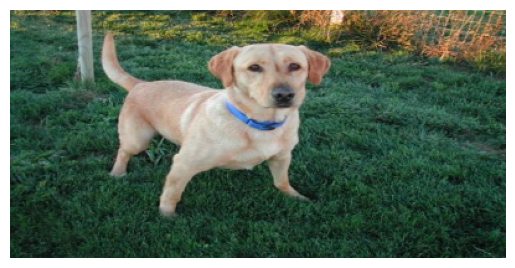

In [32]:
for images, labels in test_ds.take(1):
    img = images[0]
    true_label = labels[0].numpy()
    break

img_batch = tf.expand_dims(img, 0)
prediction = model.predict(img_batch)
print(prediction)
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")

Вероятность того, что на картинке собака, равна 0.53 - модель не очень уверена в результате.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[0.31610942]]


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

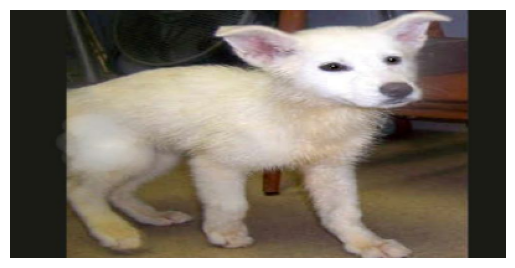

In [33]:
for images, labels in test_ds.take(1):
    img = images[5]
    true_label = labels[0].numpy()
    break

img_batch = tf.expand_dims(img, 0)
prediction = model.predict(img_batch)
print(prediction)
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")

Вероятность равна 0.31. Модель уверена в том, что на картинке кошка.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.36610273]]


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

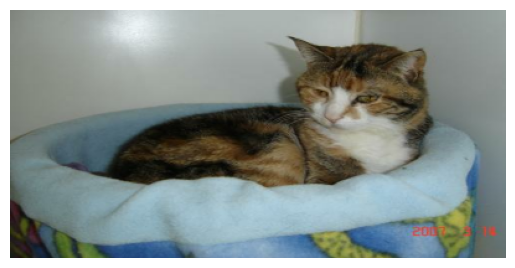

In [34]:
for images, labels in test_ds.take(1):
    img = images[31]
    true_label = labels[0].numpy()
    break

img_batch = tf.expand_dims(img, 0)
prediction = model.predict(img_batch)
print(prediction)
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")

Вероятность того, что на картинке собака - 0.32. Модель дает достаточно уверенное предсказание в том, что на картинке кошка.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.31204405]]


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

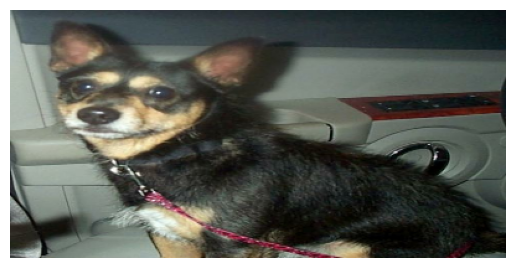

In [35]:
for images, labels in test_ds.take(1):
    img = images[1]
    true_label = labels[0].numpy()
    break

img_batch = tf.expand_dims(img, 0)
prediction = model.predict(img_batch)
print(prediction)
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")

Вероятность того, что на картинке собака - 0.28. То есть эту собаку модель с достаточно большой уверенностью считает кошкой.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.38882104]]


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

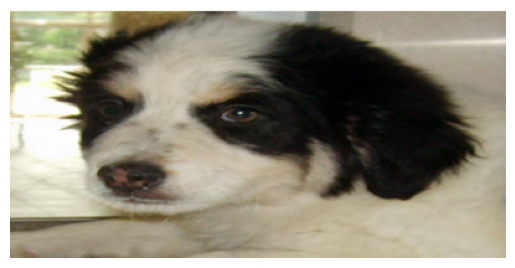

In [36]:
for images, labels in test_ds.take(1):
    img = images[7]
    true_label = labels[0].numpy()
    break

img_batch = tf.expand_dims(img, 0)
prediction = model.predict(img_batch)
print(prediction)
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")

Эту собаку модель посчитала кошкой с вероятностью 0.62.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.47302407]]


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

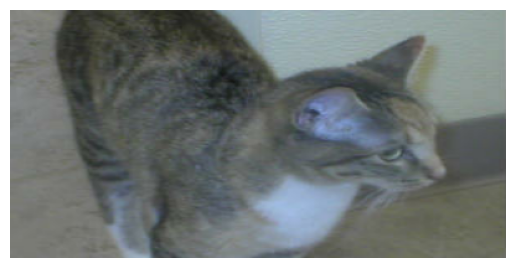

In [37]:
for images, labels in test_ds.take(1):
    img = images[12]
    true_label = labels[0].numpy()
    break

img_batch = tf.expand_dims(img, 0)
prediction = model.predict(img_batch)
print(prediction)
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")

Модель посчитала эту модель кошкой с вероятностью 0.53.

In [ ]:
for images, labels in test_ds.take(1):
    img = images[12]
    true_label = labels[0].numpy()
    break

img_batch = tf.expand_dims(img, 0)
prediction = model.predict(img_batch)
print(prediction)
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")

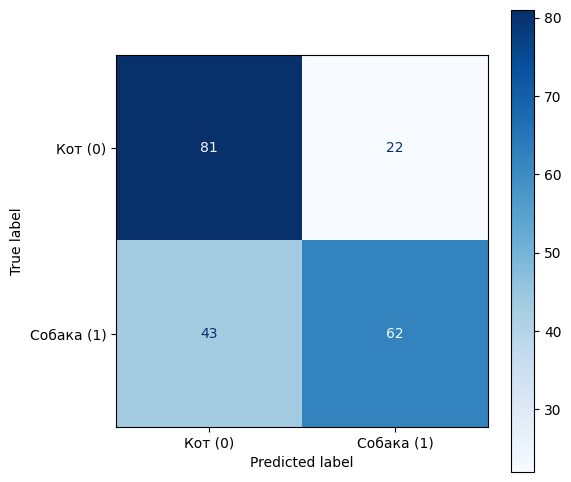

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds_classes = (preds >= 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


cm = confusion_matrix(y_true, y_pred)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Кот (0)', 'Собака (1)']
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')


Видим, что много ошибок второго рода - модель часто принимает собак за кошек.

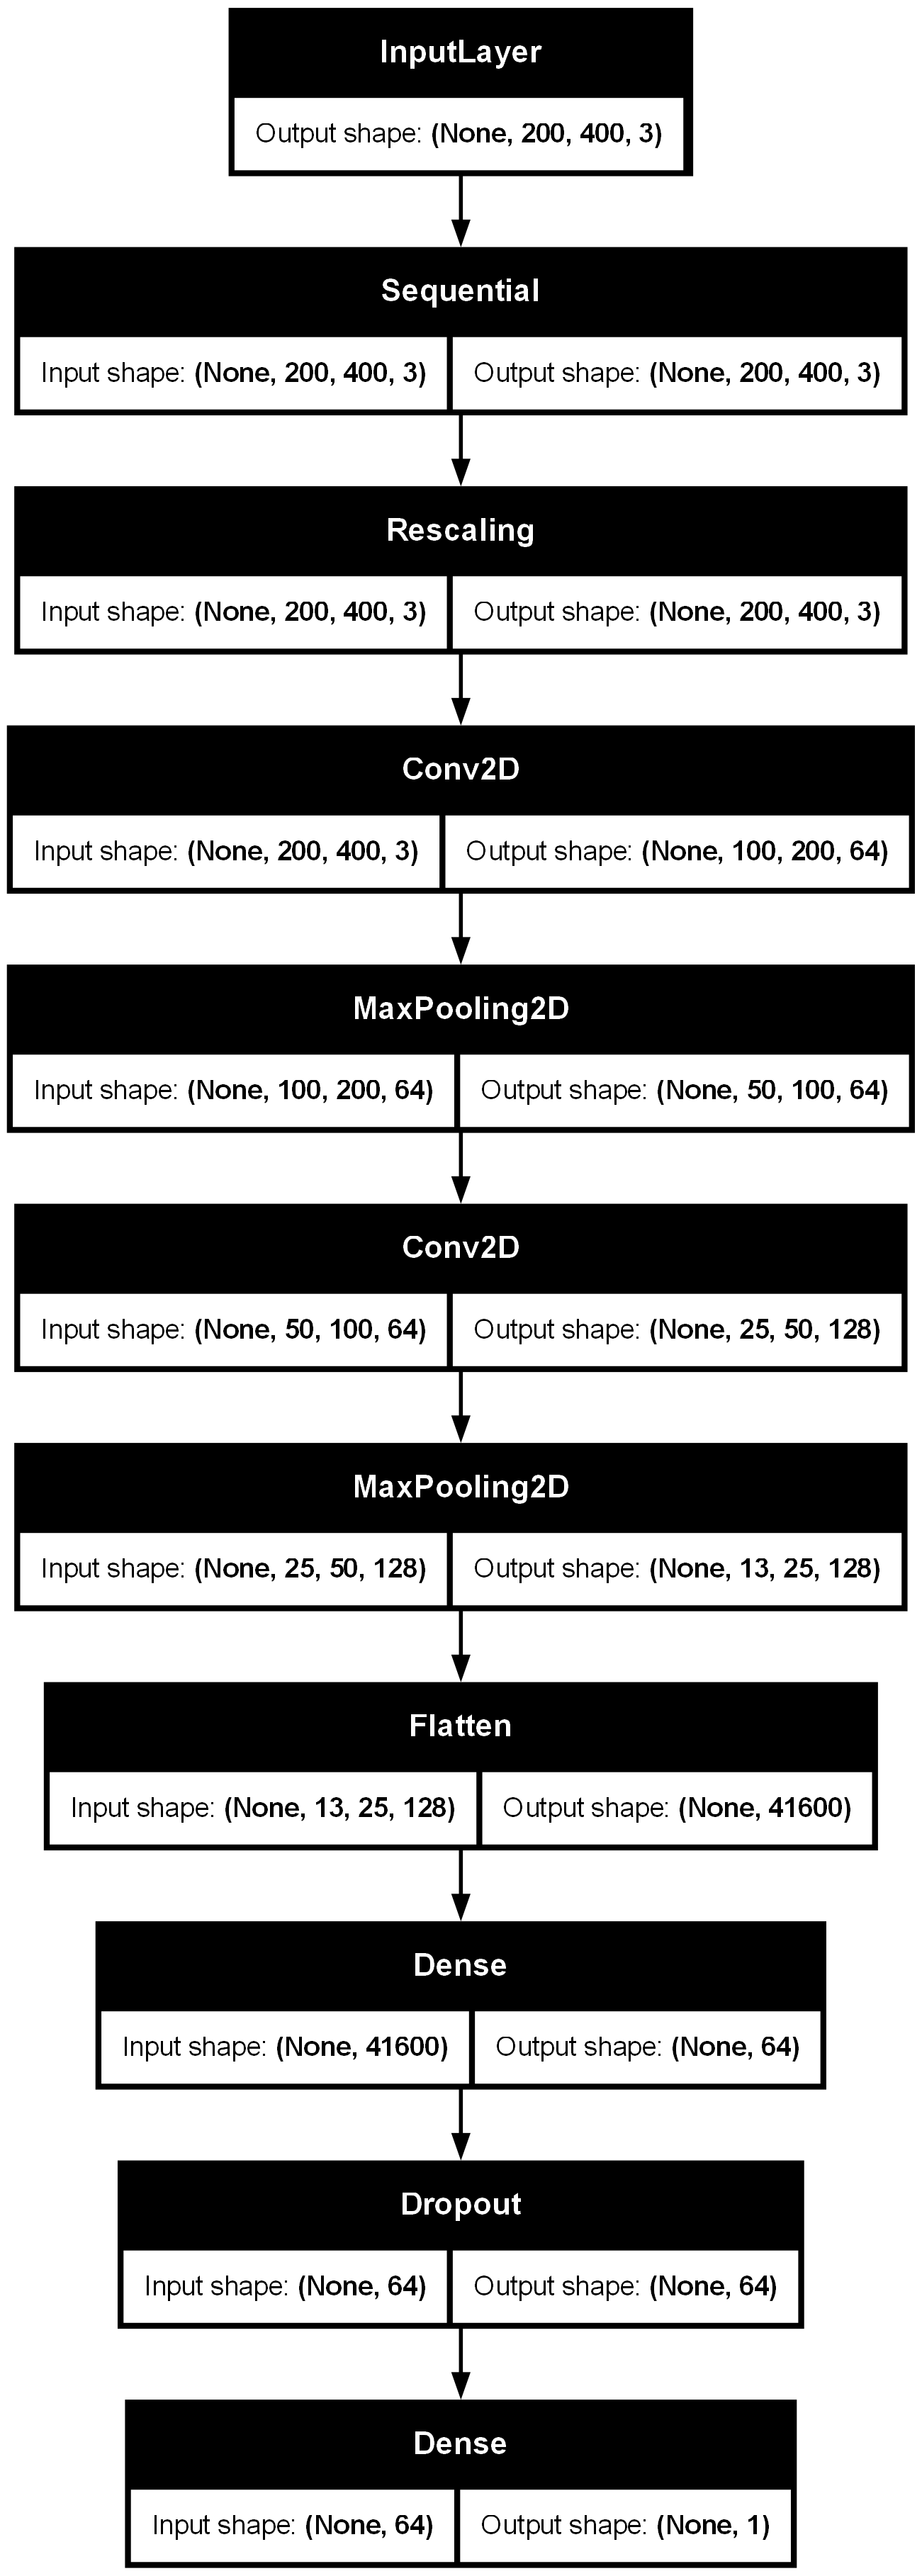

In [67]:
tf.keras.utils.plot_model(model, show_shapes=True)

Text(0.5, 1.0, 'Кривые потерь (Loss) по эпохам')

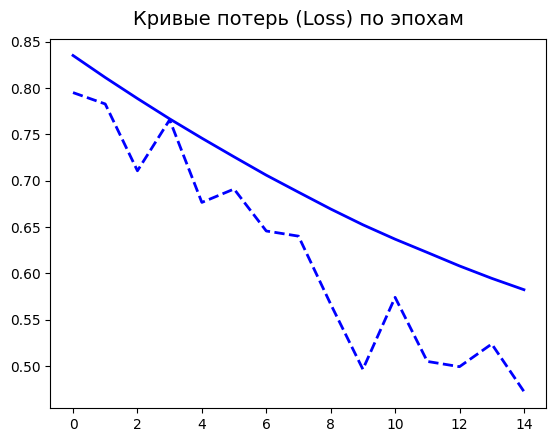

In [73]:
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(loss, 'b--', linewidth=2)
plt.plot(val_loss, 'b-', linewidth=2)

plt.title('Кривые потерь (Loss) по эпохам', fontsize=14, pad=10)

### Классификация канцелярских принадлежностей

Так как данных не очень много, то поделим их в формате 60 - 20 - 20.

In [39]:
classes = ['wrench', 'stapler', 'scissors', 'metronome']
train_ds, val_test_ds = tf.keras.utils.image_dataset_from_directory(
    "101_ObjectCategories",
    class_names=classes,
    validation_split=0.4,
    subset="both",
    seed=42,
    image_size=(299, 299),
    batch_size=32,
)
val_and_test_batches = val_test_ds.cardinality().numpy()
val_and_test_batches

Found 155 files belonging to 4 classes.
Using 93 files for training.
Using 62 files for validation.


np.int64(2)

In [40]:
half_batches = val_and_test_batches // 2
val_ds = val_test_ds.take(half_batches)
test_ds = val_test_ds.skip(half_batches)

print(f"Батчей на обучение: {train_ds.cardinality().numpy()}")
print(f"Батчей на валидацию: {val_ds.cardinality().numpy()}")
print(f"Батчей на тест: {test_ds.cardinality().numpy()}")

Батчей на обучение: 3
Батчей на валидацию: 1
Батчей на тест: 1


In [41]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.4),
    tf.keras.layers.RandomBrightness(0.3)
])

### InceptionV3

In [42]:
base_inception = tf.keras.applications.InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)

base_inception.trainable = True

for layer in base_inception.layers[:249]:
    layer.trainable = False
for layer in base_inception.layers[249:]:
    layer.trainable = True

In [43]:
inputs = tf.keras.Input(shape=(299, 299, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.inception_v3.preprocess_input(x)
x = base_inception(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model_inception = tf.keras.Model(inputs, outputs)

model_inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_inception.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,328,356 (85.18 MB)

 Trainable params: 11,640,452 (44.40 MB)

 Non-trainable params: 10,687,904 (40.77 MB)

In [65]:
tb_inc = tf.keras.callbacks.TensorBoard(log_dir="log_dir_inc", write_graph=True)
history_inception = model_inception.fit(
    train_ds,
    validation_data=val_ds,
    verbose=1,
    epochs=15,
    callbacks=[tb_inc]
)

Epoch 1/15


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7957 - loss: 0.7950 - val_accuracy: 0.8125 - val_loss: 0.8350
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7419 - loss: 0.7827 - val_accuracy: 0.8438 - val_loss: 0.8113
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8172 - loss: 0.7106 - val_accuracy: 0.8438 - val_loss: 0.7886
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7742 - loss: 0.7656 - val_accuracy: 0.8438 - val_loss: 0.7666
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8710 - loss: 0.6764 - val_accuracy: 0.8438 - val_loss: 0.7458
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8280 - loss: 0.6909 - val_accuracy: 0.8438 - val_loss: 0.7256
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8280 - loss: 0.6456 - val_accuracy: 0.8438 - val_loss: 0.7058
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8602 - loss: 0.6400 - val_accuracy: 0.8438 - val_loss: 0.6875
Epoch 9/15
3/3 ━━━━━━━━━━━━

In [45]:
%reload_ext tensorboard
%tensorboard --logdir log_dir_inc

Reusing TensorBoard on port 6007 (pid 13064), started 2:31:49 ago. (Use '!kill 13064' to kill it.)

С увеличением числа эпох значение метрики accuracy стабильно возрастает, а ошибка монотонно уменьшается.

### VGG19

In [46]:
base_vgg19 = tf.keras.applications.VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)
base_vgg19.trainable = True
for layer in base_vgg19.layers:
    if "block5_" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

In [47]:
inputs = tf.keras.Input(shape=(299, 299, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.vgg19.preprocess_input(x)
x = base_vgg19(x, training=False)


x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model_vgg19 = tf.keras.Model(inputs, outputs)

model_vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg19.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 299, 299,  │          0 │ input_layer_11[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 299, 299)  │          0 │ sequential_3[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 299, 299)  │          0 │ sequential_3[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 299, 299)  │          0 │ sequential_3[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 299, 299,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 299, 299,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 9, 9, 512) │ 20,024,384 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg19[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 4)         │      1,028 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,156,740 (76.89 MB)

 Trainable params: 9,571,588 (36.51 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

In [48]:
tb_inc = tf.keras.callbacks.TensorBoard(log_dir="log_dir_vgg19", write_graph=True)
history_vgg19 = model_vgg19.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1,
    callbacks=[tb_inc]
)

Epoch 1/15


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 8s/step - accuracy: 0.3118 - loss: 3.5656 - val_accuracy: 0.3125 - val_loss: 2.4725
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.3011 - loss: 2.6160 - val_accuracy: 0.3750 - val_loss: 2.0245
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step - accuracy: 0.3978 - loss: 1.9093 - val_accuracy: 0.3750 - val_loss: 1.7310
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 8s/step - accuracy: 0.3871 - loss: 1.9898 - val_accuracy: 0.4062 - val_loss: 1.5494
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.4086 - loss: 1.7517 - val_accuracy: 0.4062 - val_loss: 1.4391
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.6237 - loss: 1.2667 - val_accuracy: 0.5312 - val_loss: 1.3722
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step - accuracy: 0.3871 - loss: 1.5350 - val_accuracy: 0.4688 - val_loss: 1.3245
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.5054 - loss: 1.3841 - val_accuracy: 0.4688 - val_loss: 1.2779
Epoch 9/15
3/3 ━━━━

In [63]:
%reload_ext tensorboard
%tensorboard --logdir log_dir_vgg19


Reusing TensorBoard on port 6008 (pid 17616), started 2:33:12 ago. (Use '!kill 17616' to kill it.)

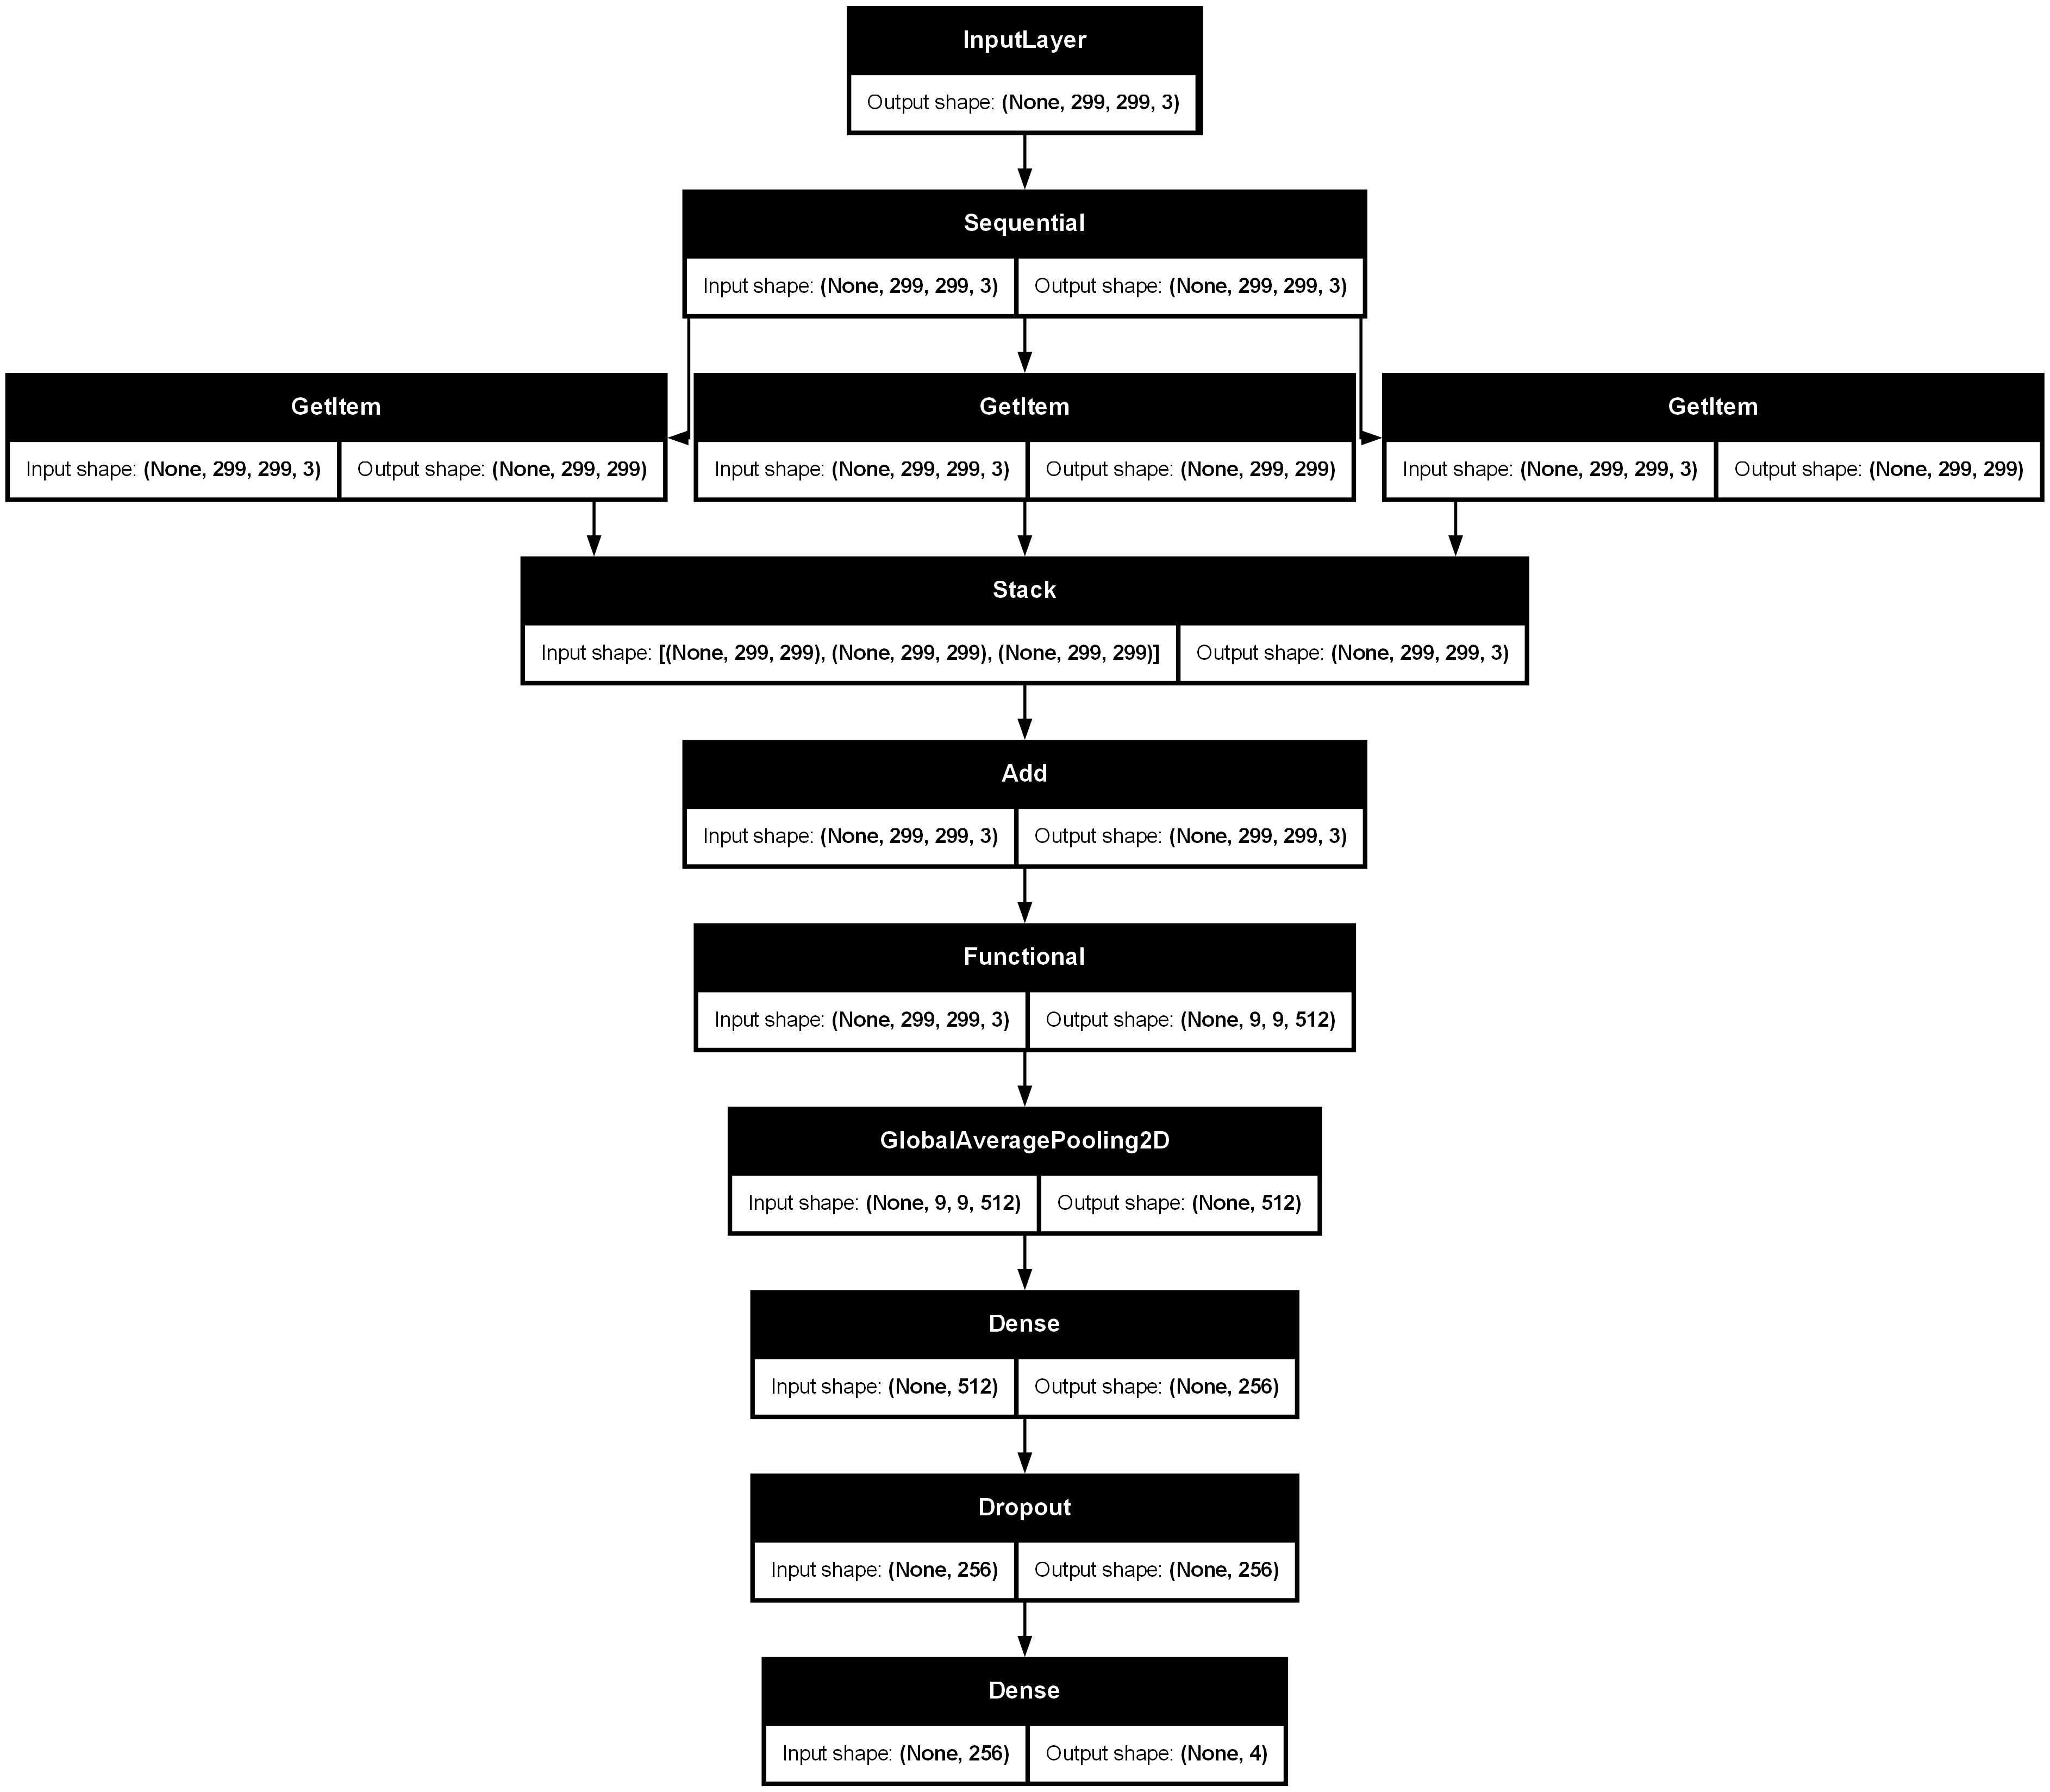

In [50]:
tf.keras.utils.plot_model(model_vgg19, show_shapes=True)


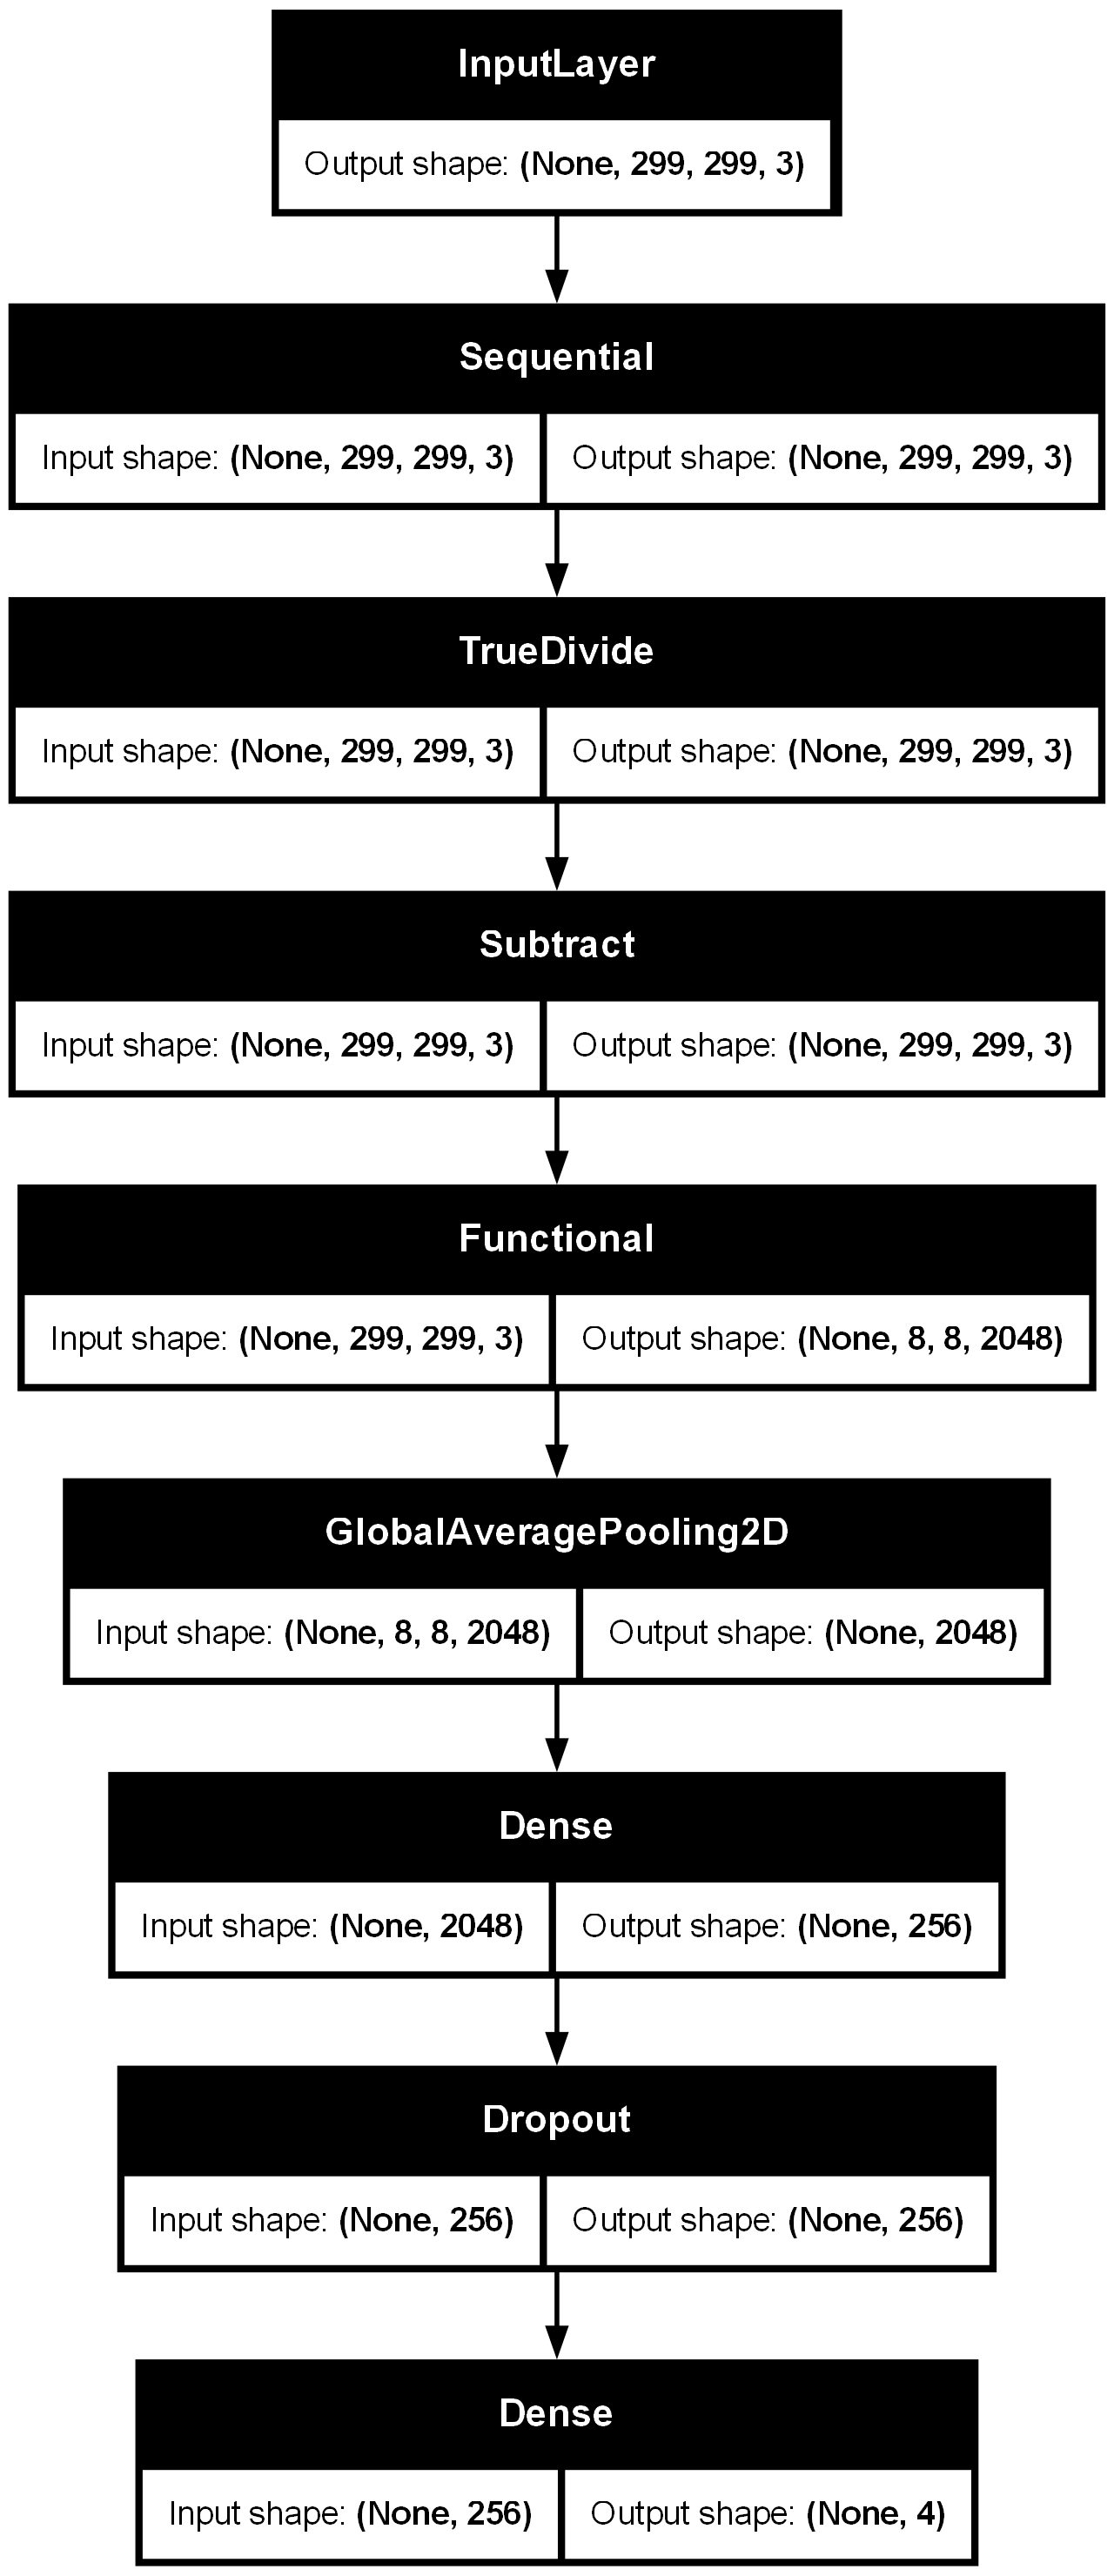

In [51]:
tf.keras.utils.plot_model(model_inception, to_file='inception_graph.png', show_shapes=True)

In [52]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics_dict(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds_classes = np.argmax(preds, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds_classes)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return {
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "F1-score": round(f1_score(y_true, y_pred, average='macro', zero_division=0), 2)
    }

vgg_train_res = get_metrics_dict(model_vgg19, train_ds)
vgg_test_res = get_metrics_dict(model_vgg19, test_ds)

inc_train_res = get_metrics_dict(model_inception, train_ds)
inc_test_res = get_metrics_dict(model_inception, test_ds)

columns = pd.MultiIndex.from_product(
    [['Train', 'Test'], ['Accuracy', 'Precision', 'Recall', 'F1-score']],
)

data = [
    list(vgg_train_res.values()) + list(vgg_test_res.values()),
    list(inc_train_res.values()) + list(inc_test_res.values())
]
df= pd.DataFrame(data, index=['VGG19', 'InceptionV3'], columns=columns)

df.index.name = 'Модель'

df

Train                                Test                    \
            Accuracy Precision  Recall F1-score Accuracy Precision  Recall   
Модель                                                                       
VGG19         0.7097    0.7056  0.7094     0.70   0.6000    0.4056  0.4896   
InceptionV3   0.7634    0.7723  0.7599     0.74   0.8333    0.8115  0.8318   

                      
            F1-score  
Модель                
VGG19           0.44  
InceptionV3     0.81

Заметим, что модель InceptionV3 (f1 = 0.81) отработала значительно лучше модели VGG19 (f1 = 0.44). Кроме того, для модели VGG19 характерно переобучение (f1 = 0.70 на трейне). Это объясняется тем, что модель InceptionV3 использует параллельные слои внутри одного модуля. Вместо одной жесткой последовательности она одновременно смотрит на картинку через свертки разного размера. Это позволяет ей одновременно улавливать и крупные формы (силуэт прибора), и мелкие детали (текстуру).



Text(0.5, 1.0, 'InceptionV3')

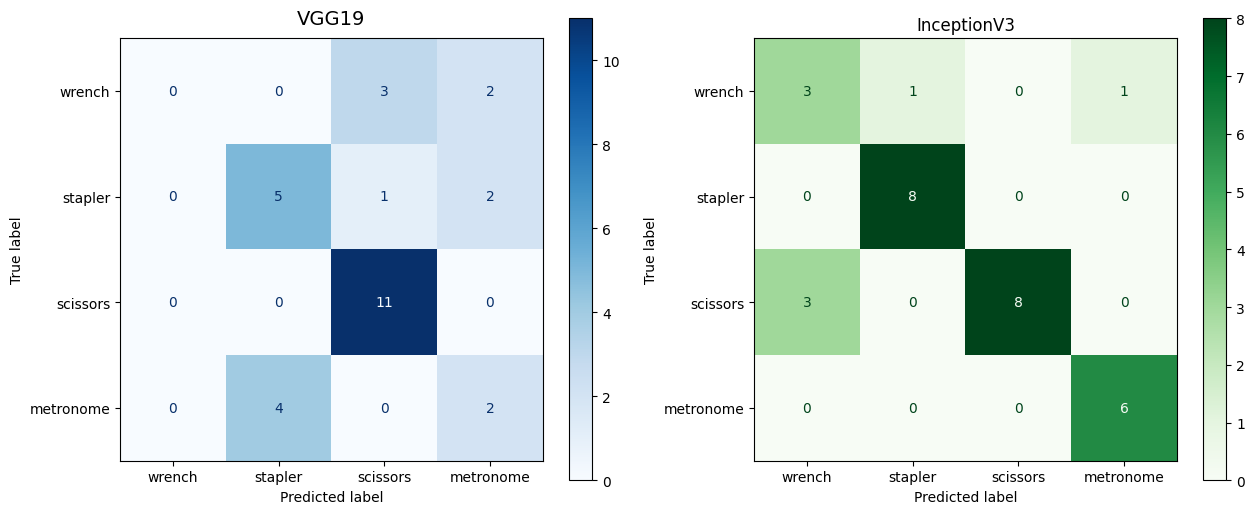

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['wrench', 'stapler', 'scissors', 'metronome']

def get_y_true_and_pred(model, dataset):
    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds_classes = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds_classes)
    return np.array(y_true), np.array(y_pred)

y_true_vgg, y_pred_vgg = get_y_true_and_pred(model_vgg19, test_ds)

y_true_inc, y_pred_inc = get_y_true_and_pred(model_inception, test_ds)

cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
cm_inc = confusion_matrix(y_true_inc, y_pred_inc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=class_names)
disp_vgg.plot(cmap=plt.cm.Blues, ax=ax1, values_format='d')
ax1.set_title('VGG19', fontsize=14, pad=10)
ax1.grid(False)

disp_inc = ConfusionMatrixDisplay(confusion_matrix=cm_inc, display_labels=class_names)
disp_inc.plot(cmap=plt.cm.Greens, ax=ax2)
ax2.set_title('InceptionV3')


По матрице видно, что модель VGG19 ошибается гораздо чаще, чем модель InceptionV3 (суммы по главным диагоналям у моделей значительно отличаются).

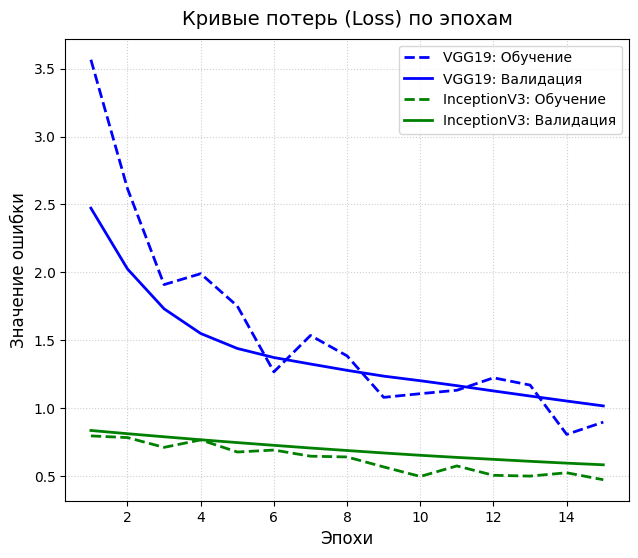

In [66]:
vgg_loss = history_vgg19.history['loss']
vgg_val_loss = history_vgg19.history['val_loss']
vgg_acc = history_vgg19.history['accuracy']
vgg_val_acc = history_vgg19.history['val_accuracy']

inc_loss = history_inception.history['loss']
inc_val_loss = history_inception.history['val_loss']
inc_acc = history_inception.history['accuracy']
inc_val_acc = history_inception.history['val_accuracy']

epochs_range = range(1, len(vgg_loss) + 1)

plt.figure(figsize=(16, 6))


plt.subplot(1, 2, 1)

plt.plot(epochs_range, vgg_loss, 'b--', linewidth=2, label='VGG19: Обучение')
plt.plot(epochs_range, vgg_val_loss, 'b-', linewidth=2, label='VGG19: Валидация')

plt.plot(epochs_range, inc_loss, 'g--', linewidth=2, label='InceptionV3: Обучение')
plt.plot(epochs_range, inc_val_loss, 'g-', linewidth=2, label='InceptionV3: Валидация')

plt.title('Кривые потерь (Loss) по эпохам', fontsize=14, pad=10)
plt.xlabel('Эпохи', fontsize=12)
plt.ylabel('Значение ошибки', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

По графику видно, что с каждой эпохой функция потерь уменьшает свое значение.